# Метод опорных векторов с полиномиальным ядром

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from pathlib import Path
import warnings
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from research_utils.learning import grid_search, iteration_learning_score, get_top_n_info
from research_utils.plot import create_panel, plot_learning_curve, plot_complexity_and_accuracy, df_hist, df_scatter, series_hist, series_scatter
from research_utils.stats import agg_by_columns
from predictors.serialization import save_model
from predictors.feature_selection import ModelFeatureSelector
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PowerTransformer
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

save = partial(save_model, models_dir)
train = pd.read_parquet("../data/processed/train.parquet")

## Подготовка данных
Метод опорных векторов:
- Чувствителен к выбросам.
- Чувствителен к мультиколлинеарности.
- Требует приведение признаков к единому масштабу
- Лучше работает при нормальном распределении

Таким образом, весь процесс предобработки будет похож на процесс предобработки логистической регресии

Для сокращения размерности будем использовать SelectKBest на непрервных признаках

In [3]:
numeric_features = {
    'text__long_sentences_proportion', 
    'text__unpopular_words_proportion',
    'text__type_token_ratio',
    'text__mean_words_length',
    'text__lexicon_size',
    'entities__breadth_of_use_entities',
    'pos__mean_usage_NOUN', 
    'pos__mean_usage_PRON', 
    'pos__mean_usage_ADV',
    'pos__mean_usage_ADP', 
    'pos__mean_usage_SCONJ',
    'pos__mean_usage_CCONJ', 
    'pos__mean_usage_VERB',
    'pos__mean_usage_PROPN', 
    'pos__mean_usage_DET', 
    'pos__mean_usage_PART',
    "pos__ADJPOS_NOUN",
    "pos__PUNCT_SCONJ",
    "pos__ADP_ADJPOS",
    "pos__ADP_PRON",
    "pos__PUNCT_ADV",
    "pos__ADJPOS_PUNCT",
    "pos__PUNCT_CCONJ",
    'pos__index_of_formality_heylinger',
    'punct__breadth_of_use_puncts', 
    "punct__mean_usage_comma"
}
combo_features = { 
    "pos__pair_of_adv_per_sentence",
    "pos__mean_usage_AUX",
    "pos__mean_usage_NUM",
    "pos__PROPN_PUNCT",
    "pos__PUNCT_PRON",
    "punct__mean_usage_colon",
    "punct__mean_usage_question",
    "punct__mean_usage_openparen",
    "punct__mean_usage_closeparen",
    "punct__mean_usage_hyphen",
    "punct__mean_usage_exclamation",
    "entities__mean_usage_NUMBER",
    "entities__mean_usage_QUOTE",
    "entities__mean_usage_PUNCEM",
    "entities__mean_usage_ADDRESS",
}
combo_flags = { f"{col}_used" for col in combo_features }
typical_features = {
    'entities__mean_usage_MEAS_is_typical',
    'entities__mean_usage_ENUM_is_typical',
    'entities__mean_usage_FOREIGN_is_typical',
    'pos__breadth_of_use_pos_is_typical',
    'pos__index_of_formality_tuldava_is_typical',
    'entities__mean_usage_SMILE_is_typical',
    'entities__mean_usage_DATE_is_typical'
}
features = numeric_features | combo_features | combo_flags | typical_features
features_list = list(features)

In [ ]:
cs = [ 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 25, 50, 100 ]
n_numeric_features = [10, 13, 16, 18, 21, 'all']
degrees = [2, 3]

pipeline_params = {
    'preprocessing__numeric__select_kbest__k': n_numeric_features,
    'model__C': cs,
    'model__degree': degrees,
    'model__kernel': ["poly"],
    "model__class_weight": [ 'balanced' ],
    "model__random_state": [ 42 ],
    "model__probability": [True],
}

numeric_fix_list = list(numeric_features.difference([
    "punct__breadth_of_use_puncts",
    "entities__breadth_of_use_entities",
    "pos__index_of_formality_heylinger",
    "text__type_token_ratio"
]))
combo_fix_list = list(combo_features)

def create_svc_poly_pipeline(model_params=None):
    if not model_params:
        model_params = {}
    
    return Pipeline([
        ('get_features', ModelFeatureSelector(features_list)),
        
        ('power_transform', ColumnTransformer([
            ('numeric_power', PowerTransformer(method='yeo-johnson', standardize=False), 
             [features_list.index(f) for f in numeric_fix_list]),
            ('combo_power', PowerTransformer(method='yeo-johnson', standardize=False), 
             [features_list.index(f) for f in combo_fix_list]),
        ], remainder='passthrough')),
        
        ('preprocessing', ColumnTransformer([
            ('binary', RobustScaler(), [features_list.index(f) for f in typical_features]),
            ('numeric', Pipeline([
                ('scaler', RobustScaler()),
                ('select_kbest', SelectKBest(score_func=f_classif, k='all'))
            ]), [features_list.index(f) for f in numeric_features]),
            ('combo_intensive', RobustScaler(), [features_list.index(f) for f in combo_features]),
            ('combo_flag', RobustScaler(), [features_list.index(f) for f in combo_flags]),
        ], remainder='passthrough')),
        
        ('model', SVC(**model_params))
    ])

## Независимые модели

### Классификатор пола

In [ ]:
gender_pipeline = create_svc_poly_pipeline()

gender_gs = grid_search(gender_pipeline, pipeline_params, train, train['gender'])

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [8]:
gender_gs.best_params_, gender_gs.best_score_

({'model__C': 0.5,
  'model__class_weight': 'balanced',
  'model__degree': 2,
  'model__kernel': 'poly',
  'model__random_state': 42,
  'preprocessing__numeric__select_kbest__k': 'all'},
 np.float64(0.6749090909090908))

In [9]:
gender_top_5_info = get_top_n_info(gender_gs, n=5)
gender_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__degree,param_model__kernel,param_model__random_state,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
41,14.128527,0.206246,0.552870,0.051704,0.5,balanced,2,poly,42,all,"{'model__C': 0.5, 'model__class_weight': 'bala...",0.655065,0.675325,0.677922,0.685195,0.681039,0.674909,0.010454,1
50,11.978916,0.210628,0.486489,0.037266,1.0,balanced,2,poly,42,16,"{'model__C': 1, 'model__class_weight': 'balanc...",0.647792,0.675844,0.680519,0.687273,0.673247,0.672935,0.013445,2
40,14.099490,0.478549,0.557059,0.091729,0.5,balanced,2,poly,42,21,"{'model__C': 0.5, 'model__class_weight': 'bala...",0.650909,0.672208,0.676364,0.684675,0.678961,0.672623,0.011585,3
38,12.241459,0.535284,0.478882,0.022690,0.5,balanced,2,poly,42,16,"{'model__C': 0.5, 'model__class_weight': 'bala...",0.647273,0.670130,0.679481,0.692468,0.672727,0.672416,0.014761,4
45,13.365379,0.550729,0.524651,0.036666,0.5,balanced,3,poly,42,18,"{'model__C': 0.5, 'model__class_weight': 'bala...",0.655584,0.676883,0.669091,0.677403,0.682597,0.672312,0.009410,5


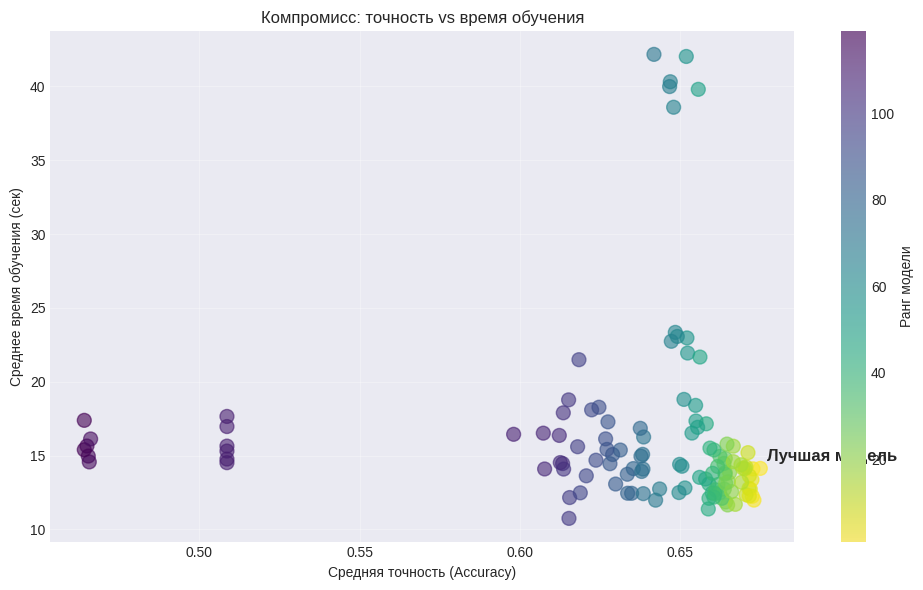

In [10]:
plot_complexity_and_accuracy(gender_gs)

In [ ]:
gender_best_model_params = {
  'model__C': 0.5,
  'model__class_weight': 'balanced',
  'model__degree': 2,
  'model__kernel': 'poly',
  'model__random_state': 42,
  "model__probability": True,
  'preprocessing__numeric__select_kbest__k': 'all'
}

In [ ]:
gender_best_model = create_svc_poly_pipeline()
gender_best_model.set_params(**gender_best_model_params)
gender_best_model_iter_learning_score = iteration_learning_score(gender_best_model, train, train['gender'])

In [ ]:
alt_gender_model = create_svc_poly_pipeline()
alt_gender_model.set_params(**
{
    'model__C': 0.5,
    'model__class_weight': 'balanced',
    'model__degree': 2,
    'model__kernel': 'poly',
    'model__random_state': 42,
    "model__probability": True,
    'preprocessing__numeric__select_kbest__k': 10
}
)
alt_gender_model_iter_learning_score = iteration_learning_score(alt_gender_model, train, train['gender'])

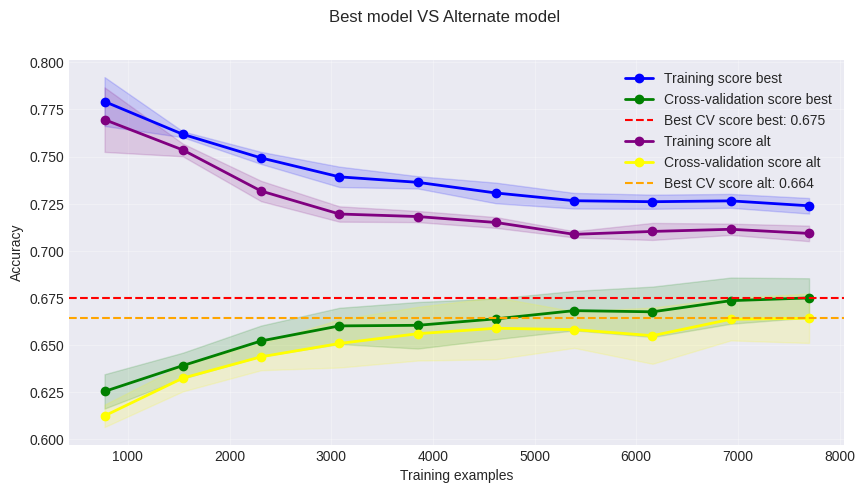

In [14]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*gender_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_gender_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternate model")
plt.show()

Для сравнения использовались 2 конфигурации:
- Конфигурация с лучшим счетом по GS
- Конфигурация с регуляризацией через меньшее кол-во признаков

Лучший показатель - 67,5%. Регуляризация путем минимизации кол-ва признаков показывает точность на 1,5% ниже (Из 26 признаков остается 10)

In [15]:
gender_best_model.fit(train, train['gender'])
save(
    gender_best_model, 
    "svc_poly_gender_best", 
    gender_best_model_params, 
    { "val": gender_best_model_iter_learning_score[2].tolist(), "train": gender_best_model_iter_learning_score[1].tolist() }
)

### Классификатор возраста

In [16]:
age_pipeline = create_svc_poly_pipeline()

age_gs = grid_search(age_pipeline, pipeline_params, train, train['age'])

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [17]:
age_gs.best_params_, age_gs.best_score_

({'model__C': 1,
  'model__class_weight': 'balanced',
  'model__degree': 2,
  'model__kernel': 'poly',
  'model__random_state': 42,
  'preprocessing__numeric__select_kbest__k': 'all'},
 np.float64(0.6214025974025974))

In [18]:
age_top_5_info = get_top_n_info(age_gs, n=5)
age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__degree,param_model__kernel,param_model__random_state,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
53,15.138208,0.273110,0.646441,0.044658,1.0,balanced,2,poly,42,all,"{'model__C': 1, 'model__class_weight': 'balanc...",0.621818,0.627013,0.610390,0.613506,0.634286,0.621403,0.008732,1
41,15.495221,0.589403,0.900637,0.113253,0.5,balanced,2,poly,42,all,"{'model__C': 0.5, 'model__class_weight': 'bala...",0.616104,0.619740,0.614026,0.622338,0.633247,0.621091,0.006722,2
51,13.680236,0.485526,0.496520,0.033917,1.0,balanced,2,poly,42,18,"{'model__C': 1, 'model__class_weight': 'balanc...",0.618182,0.618701,0.610390,0.615065,0.642078,0.620883,0.011002,3
52,14.648921,0.600119,0.708251,0.124786,1.0,balanced,2,poly,42,21,"{'model__C': 1, 'model__class_weight': 'balanc...",0.618182,0.629610,0.611948,0.610390,0.624935,0.619013,0.007380,4
47,16.062353,0.387124,0.836607,0.079985,0.5,balanced,3,poly,42,all,"{'model__C': 0.5, 'model__class_weight': 'bala...",0.609870,0.629091,0.608312,0.617662,0.629610,0.618909,0.009097,5


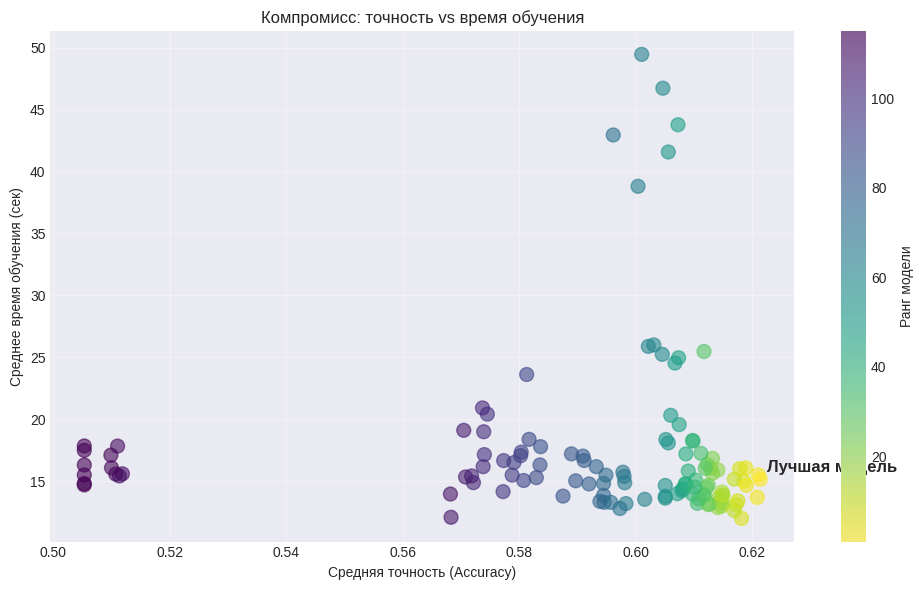

In [20]:
plot_complexity_and_accuracy(age_gs)

In [ ]:
age_best_model_params = {
  'model__C': 1,
  'model__class_weight': 'balanced',
  'model__degree': 2,
  'model__kernel': 'poly',
  'model__random_state': 42,
  "model__probability": True,
  'preprocessing__numeric__select_kbest__k': 'all'
}

In [ ]:
age_best_model = create_svc_poly_pipeline()
age_best_model.set_params(**age_best_model_params)
age_best_model_iter_learning_score = iteration_learning_score(age_best_model, train, train['age'])

In [ ]:
alt_age_model = create_svc_poly_pipeline()
alt_age_model.set_params(**
{
    'model__C': 1,
    'model__class_weight': 'balanced',
    'model__degree': 2,
    'model__kernel': 'poly',
    'model__random_state': 42,
    "model__probability": True,
    'preprocessing__numeric__select_kbest__k': 10
}
)
alt_age_model_iter_learning_score = iteration_learning_score(alt_age_model, train, train['age'])

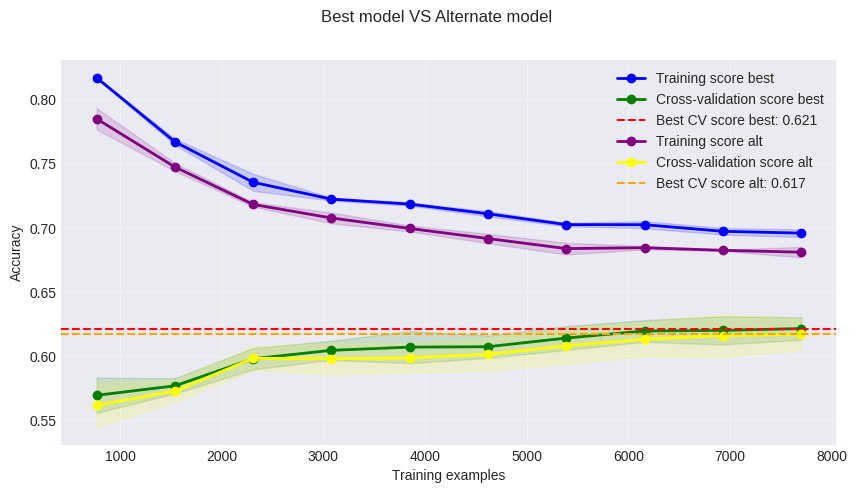

In [23]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternate model")
plt.show()

Лучшая точность - 62.1%. 

In [24]:
age_best_model.fit(train, train['age'])
save(
    age_best_model, 
    "svc_poly_age_best", 
    age_best_model_params, 
    { "val": age_best_model_iter_learning_score[2].tolist(), "train": age_best_model_iter_learning_score[1].tolist() }
)

## Каскадный подход

Прогнозирование пола показывает более высокий показатель точности, по сравнению с прогнозирование возрастной группы. По этой причине сначала будет прогнозироваться пол, а затем в рамках пола - возраст

### Прогнозирование возраста мужчин

In [9]:
men_train = train[train['gender'] == 1]

In [ ]:
man_age_pipeline = create_svc_poly_pipeline()

men_age_gs = grid_search(man_age_pipeline, pipeline_params, men_train, men_train['age'])

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [26]:
men_age_gs.best_params_, men_age_gs.best_score_

({'model__C': 0.5,
  'model__class_weight': 'balanced',
  'model__degree': 3,
  'model__kernel': 'poly',
  'model__random_state': 42,
  'preprocessing__numeric__select_kbest__k': 18},
 np.float64(0.6188231707093083))

In [27]:
men_age_top_5_info = get_top_n_info(men_age_gs, n=5)
men_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__degree,param_model__kernel,param_model__random_state,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
45,2.614832,0.587174,0.147453,0.010185,0.5,balanced,3,poly,42,18,"{'model__C': 0.5, 'model__class_weight': 'bala...",0.619732,0.613027,0.604406,0.627996,0.628955,0.618823,0.009264,1
52,2.862380,0.331371,0.153460,0.025627,1.0,balanced,2,poly,42,21,"{'model__C': 1, 'model__class_weight': 'balanc...",0.625479,0.600575,0.617816,0.633749,0.616491,0.618822,0.011014,2
53,3.271053,0.169366,0.161955,0.004617,1.0,balanced,2,poly,42,all,"{'model__C': 1, 'model__class_weight': 'balanc...",0.624521,0.590038,0.618774,0.634708,0.625120,0.618632,0.015184,3
44,2.416338,0.302612,0.138905,0.004095,0.5,balanced,3,poly,42,16,"{'model__C': 0.5, 'model__class_weight': 'bala...",0.622605,0.612069,0.602490,0.627037,0.618408,0.616522,0.008577,4
30,2.505065,0.320208,0.175340,0.009066,0.1,balanced,3,poly,42,10,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.597701,0.636973,0.607280,0.616491,0.624161,0.616521,0.013537,5


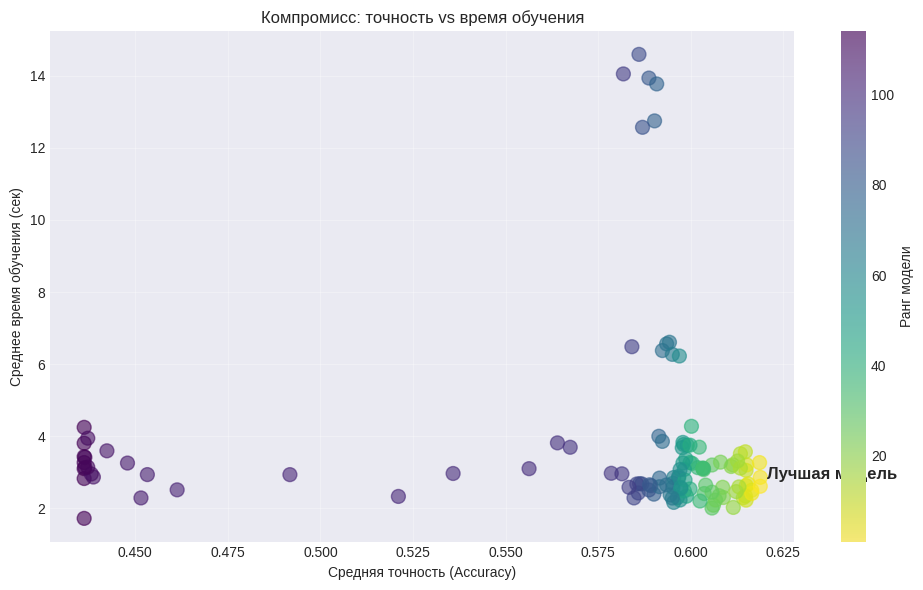

In [28]:
plot_complexity_and_accuracy(men_age_gs)

In [ ]:
men_age_best_model_params = {
    'model__C': 0.5,
    'model__class_weight': 'balanced',
    'model__degree': 3,
    'model__kernel': 'poly',
    'model__random_state': 42,
    "model__probability": True,
    'preprocessing__numeric__select_kbest__k': 18
}

In [ ]:
men_age_best_model = create_svc_poly_pipeline()
men_age_best_model.set_params(**men_age_best_model_params)
men_age_best_model_iter_learning_score = iteration_learning_score(men_age_best_model, men_train, men_train['age'])

In [ ]:
alt_men_age_model = create_svc_poly_pipeline()
alt_men_age_model.set_params(**
{
    'model__C': 0.5,
    'model__class_weight': 'balanced',
    'model__degree': 3,
    'model__kernel': 'poly',
    'model__random_state': 42,
    "model__probability": True,
    'preprocessing__numeric__select_kbest__k': 'all'
}
)
alt_men_age_model_iter_learning_score = iteration_learning_score(alt_men_age_model, men_train, men_train['age'])

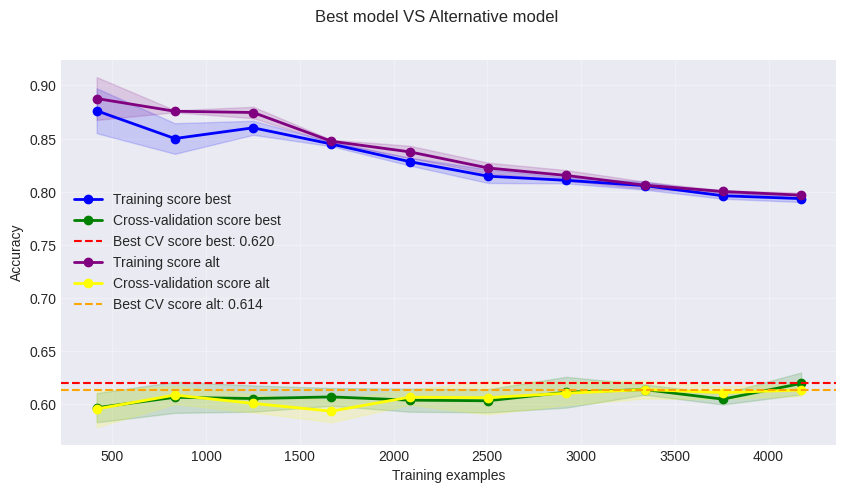

In [31]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*men_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_men_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Определение возраста в мужской подвыборке имеет такую-же точность, как и общая модель (независимая). 

In [32]:
men_age_best_model.fit(men_train, men_train['age'])
save(
    men_age_best_model, 
    "svc_poly_men_age_best", 
    men_age_best_model_params, 
    { "val": men_age_best_model_iter_learning_score[2].tolist(), "train": men_age_best_model_iter_learning_score[1].tolist() }
)

### Прогнозирование возраста женщин

In [12]:
women_train = train[train['gender'] == 0]

In [ ]:
woman_age_pipeline = create_svc_poly_pipeline()

women_age_gs = grid_search(woman_age_pipeline, pipeline_params, women_train, women_train['age'])

In [34]:
women_age_gs.best_params_, women_age_gs.best_score_

({'model__C': 0.01,
  'model__class_weight': 'balanced',
  'model__degree': 3,
  'model__kernel': 'poly',
  'model__random_state': 42,
  'preprocessing__numeric__select_kbest__k': 21},
 np.float64(0.6346738014161397))

In [35]:
women_age_top_5_info = get_top_n_info(women_age_gs, n=5)
women_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__degree,param_model__kernel,param_model__random_state,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
22,2.094833,0.241590,0.150801,0.024068,0.01,balanced,3,poly,42,21,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.636054,0.625850,0.635641,0.635641,0.640182,0.634674,0.004732,1
23,2.131621,0.332215,0.136571,0.003890,0.01,balanced,3,poly,42,all,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.647392,0.626984,0.635641,0.620885,0.639047,0.633990,0.009260,2
21,1.713159,0.299352,0.127637,0.019529,0.01,balanced,3,poly,42,18,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.630385,0.633787,0.626561,0.636776,0.629966,0.631495,0.003495,3
19,1.443087,0.121748,0.105217,0.016555,0.01,balanced,3,poly,42,13,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.623583,0.629252,0.622020,0.636776,0.634506,0.629228,0.005808,4
95,1.773115,0.060636,0.099012,0.005708,25.00,balanced,3,poly,42,all,"{'model__C': 25, 'model__class_weight': 'balan...",0.624717,0.621315,0.622020,0.635641,0.641317,0.629002,0.008024,5


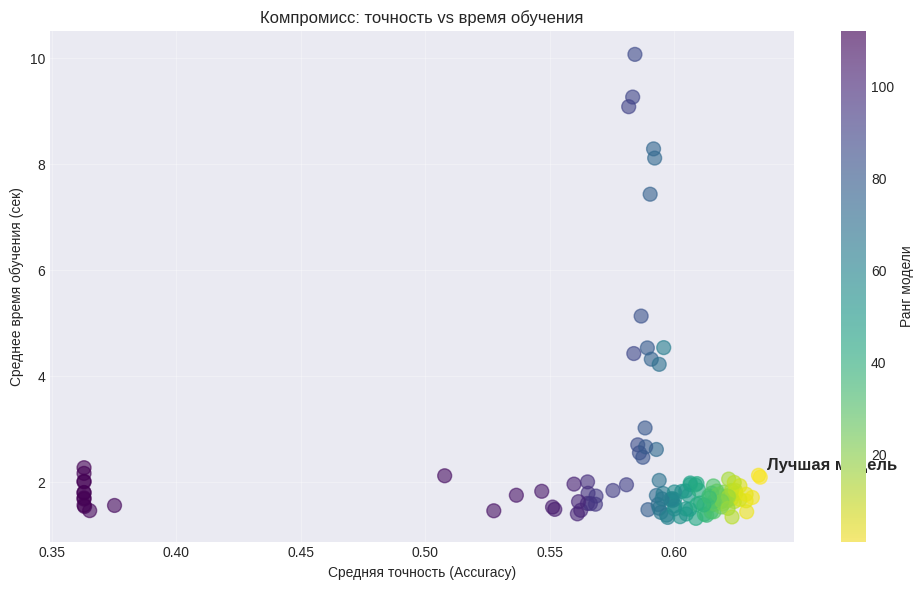

In [36]:
plot_complexity_and_accuracy(women_age_gs)

In [ ]:
women_age_best_model_params = { 
    'model__C': 0.01,
    'model__class_weight': 'balanced',
    'model__degree': 3,
    'model__kernel': 'poly',
    'model__random_state': 42,
    "model__probability": True,
    'preprocessing__numeric__select_kbest__k': 21
}

In [ ]:
women_age_best_model = create_svc_poly_pipeline()
women_age_best_model.set_params(**women_age_best_model_params)
women_age_best_model_iter_learning_score = iteration_learning_score(women_age_best_model, women_train, women_train['age'])

In [ ]:
alt_women_age_model = create_svc_poly_pipeline()
alt_women_age_model.set_params(**
{
    'model__C': 0.01,
    'model__class_weight': 'balanced',
    'model__degree': 3,
    'model__kernel': 'poly',
    'model__random_state': 42,
    "model__probability": True,
    'preprocessing__numeric__select_kbest__k': 'all'
}
)
alt_women_age_model_iter_learning_score = iteration_learning_score(alt_women_age_model, women_train, women_train['age'])

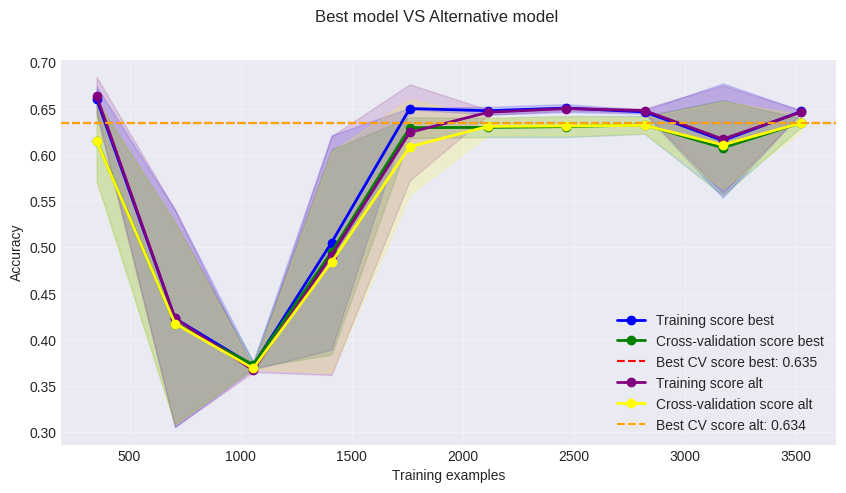

In [39]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*women_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_women_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Использование метода опорных векторов с полиномиальным ядром имеет слегка повышает точность в каскадном подходе на 1.5% 

In [40]:
women_age_best_model.fit(women_train, women_train['age'])
save(
    women_age_best_model, 
    "svc_poly_women_age_best", 
    women_age_best_model_params, 
    { "val": women_age_best_model_iter_learning_score[2].tolist(), "train": women_age_best_model_iter_learning_score[1].tolist() }
)

## Плоский подход

In [15]:
flat_y_train = train['gender'] * 2 + train['age']

In [42]:
flat_pipeline = create_svc_poly_pipeline()

flat_gs = grid_search(flat_pipeline, pipeline_params, train, flat_y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [43]:
flat_gs.best_params_, flat_gs.best_score_

({'model__C': 1,
  'model__class_weight': 'balanced',
  'model__degree': 3,
  'model__kernel': 'poly',
  'model__random_state': 42,
  'preprocessing__numeric__select_kbest__k': 21},
 np.float64(0.42223376623376624))

In [44]:
flat_top_5_info = get_top_n_info(flat_gs, n=5)
flat_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__degree,param_model__kernel,param_model__random_state,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
58,19.490569,2.345636,0.805802,0.097116,1.0,balanced,3,poly,42,21,"{'model__C': 1, 'model__class_weight': 'balanc...",0.403636,0.405195,0.417662,0.438442,0.446234,0.422234,0.017296,1
59,22.184154,1.111584,0.983706,0.054490,1.0,balanced,3,poly,42,all,"{'model__C': 1, 'model__class_weight': 'balanc...",0.406234,0.394805,0.412987,0.431688,0.443117,0.417766,0.017433,2
57,17.951980,1.066021,0.623305,0.126568,1.0,balanced,3,poly,42,18,"{'model__C': 1, 'model__class_weight': 'balanc...",0.396883,0.399481,0.423896,0.419221,0.433247,0.414545,0.014128,3
71,21.378472,1.407338,0.898411,0.110268,5.0,balanced,3,poly,42,all,"{'model__C': 5, 'model__class_weight': 'balanc...",0.422338,0.415584,0.401558,0.420779,0.411948,0.414442,0.007430,4
53,21.145669,0.926982,0.921626,0.145035,1.0,balanced,2,poly,42,all,"{'model__C': 1, 'model__class_weight': 'balanc...",0.396883,0.392727,0.418182,0.431688,0.431688,0.414234,0.016664,5


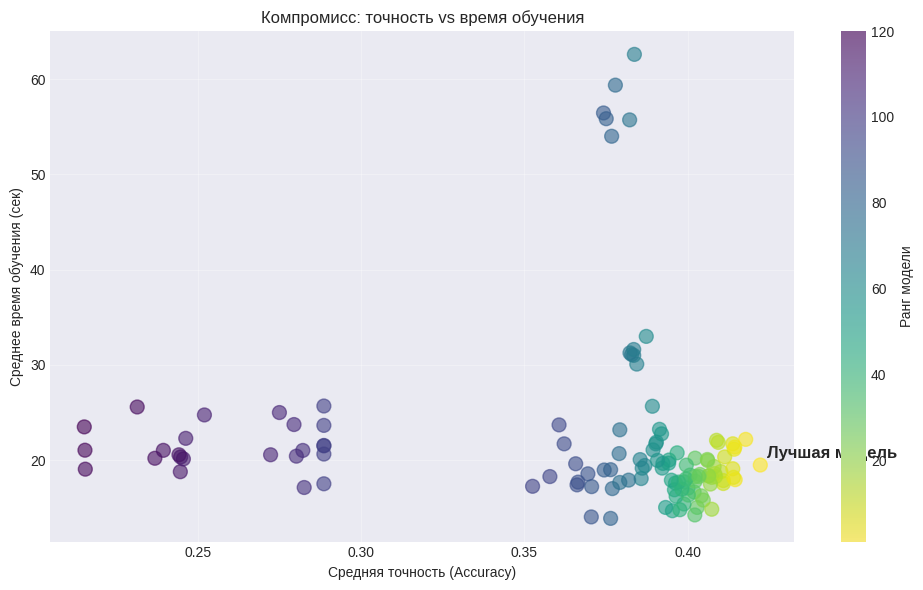

In [45]:
plot_complexity_and_accuracy(flat_gs)

In [ ]:
flat_best_model_params = {
    'model__C': 1,
    'model__class_weight': 'balanced',
    'model__degree': 3,
    'model__kernel': 'poly',
    'model__random_state': 42,
    "model__probability": True,
    'preprocessing__numeric__select_kbest__k': 21
}

In [ ]:
flat_best_model = create_svc_poly_pipeline()
flat_best_model.set_params(**flat_best_model_params)
flat_best_model_iter_learning_score = iteration_learning_score(flat_best_model, train, flat_y_train)

In [ ]:
flat_alt_model = create_svc_poly_pipeline()
flat_alt_model.set_params(**{
    'model__C': 1,
    'model__class_weight': 'balanced',
    'model__degree': 3,
    'model__kernel': 'poly',
    'model__random_state': 42,
    "model__probability": True,
    'preprocessing__numeric__select_kbest__k': 'all'
})
flat_alt_model_iter_learning_score = iteration_learning_score(flat_alt_model, train, flat_y_train)

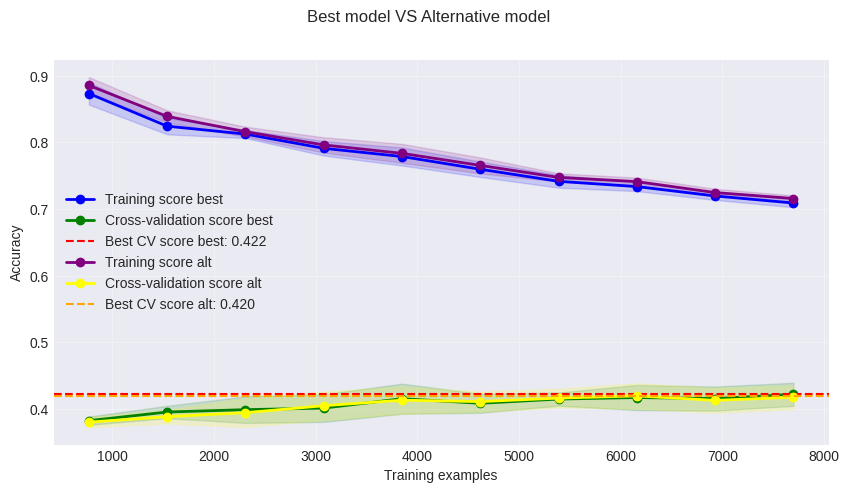

In [48]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*flat_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*flat_alt_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Точность каскадного подхода приблизительно составит `0.675 * 0.621 = 0.419`. Плоский подход имеет схожую точность

In [49]:
flat_best_model.fit(train, flat_y_train)
save(
    flat_best_model, 
    "svc_poly_flat_best", 
    flat_best_model_params, 
    { "val": flat_best_model_iter_learning_score[2].tolist(), "train": flat_best_model_iter_learning_score[1].tolist() }
)